# Gradient Boosting Classifier

Decision trees hit a ceiling around F1 ≈ 0.45 / AUC ≈ 0.85 on this data.
Gradient boosting addresses the two root causes:

| DT limitation | GBM fix |
|---|---|
| Hard axis-aligned splits -> coarse probability estimates | Ensemble of 100s of weak learners -> smoother, better-calibrated probabilities |
| Class weight shifts only the split criterion | `scale_pos_weight` / `class_weight` acts on every boosting round |
| Interactions require exponential depth | Residual boosting learns interactions across rounds |
| One regularisation knob (`max_depth`) | Shrinkage + subsampling + L1/L2 regularisation |

Two models are compared on the **same base features** and **same seed/split** as every
other notebook in this project:

- **XGBoost** (`scale_pos_weight` for imbalance, `tree_method='hist'` for speed)
- **HistGradientBoostingClassifier** (sklearn, `class_weight='balanced'`)

A small grid search over `max_depth` x `learning_rate` is run for each, using early
stopping on a held-out validation split. Final metrics are reported on the test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
)

path   = '../Data/SyntheticData/2026_05_23_15_21_27/std_synthetic_data_2026_05_23_15_21_27.csv'
df     = pd.read_csv(path)
target = 'Problem_SKU'
seed   = 1337

numeric_features = [
    'Global_SKU_Defect_Rate_%_std', 'ABS_Volume_Difference_std',
    'Aisle_Hold_%_std', '#_Pick_Events_std', '#_Pick_Events_In_Clique_std',
    '#_Picks_std', '#_Picks_In_Clique_std', 'Time_In_Loc_std', 'Current_Max_Volume_std',
]
size_dummies  = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)
defect_linked = df['Defect_In_Linked_Receive'].astype(int)
X = pd.concat([df[numeric_features], size_dummies, defect_linked], axis=1)
y = df[target].astype(int)

# 80/20 train-test (same as all other notebooks)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
# Further split train -> 80% fit / 20% val for early-stopping model selection
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=seed, stratify=y_train
)

pos_weight = float((y_fit == 0).sum()) / float((y_fit == 1).sum())
print(f'Fit: {X_fit.shape}   Val: {X_val.shape}   Test: {X_test.shape}')
print(f'Positive rate (fit): {y_fit.mean():.3f}')
print(f'pos_weight         : {pos_weight:.2f}')

# ---- Shared helpers -------------------------------------------------------
def threshold_sweep(proba, y_true):
    best_f1, best_t, best_p, best_r = 0.0, 0.5, 0.0, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
            best_p = precision_score(y_true, preds, zero_division=0)
            best_r = recall_score(y_true, preds, zero_division=0)
    return best_f1, best_p, best_r, best_t

def test_metrics(model, label):
    proba = model.predict_proba(X_test)[:, 1]
    f1, p, r, t = threshold_sweep(proba, y_test)
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    return dict(label=label, proba=proba, f1=f1, p=p, r=r, t=t, auc=auc, ap=ap)

Fit: (176000, 13)   Val: (44000, 13)   Test: (55000, 13)
Positive rate (fit): 0.074
pos_weight         : 12.58


 depth     lr   trees   val_AUC   val_AP   val_F1
----------------------------------------------------
     4   0.05     278    0.8717   0.5010   0.4876
     4   0.10     128    0.8712   0.5002   0.4868
     6   0.05     169    0.8705   0.4953   0.4831
     6   0.10     104    0.8696   0.4948   0.4902
     8   0.05     136    0.8685   0.4905   0.4833
     8   0.10      62    0.8660   0.4821   0.4752

Best XGBoost: depth=6  lr=0.1  trees=104  val_F1=0.4902


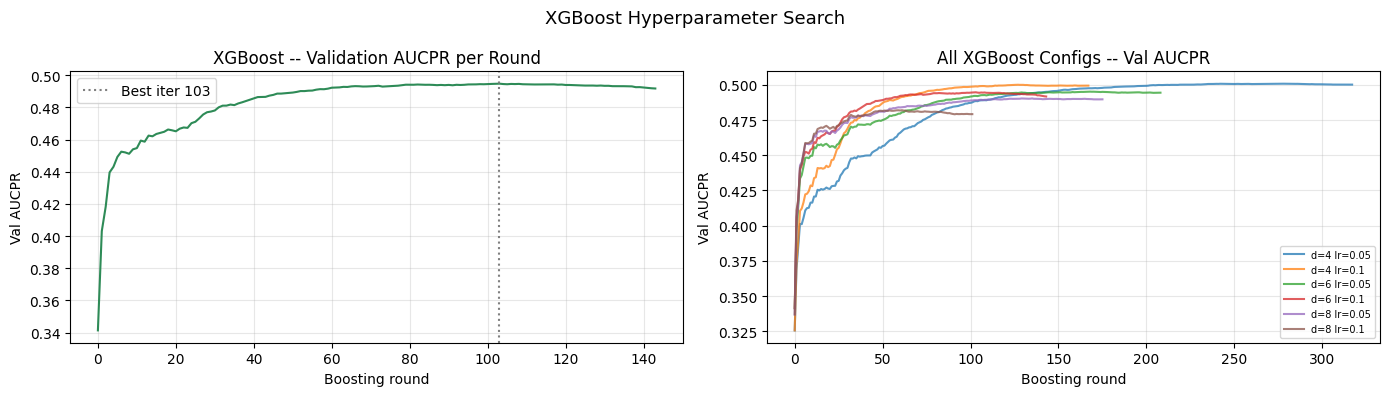

In [2]:
xgb_grid = [
    {'max_depth': 4, 'learning_rate': 0.05},
    {'max_depth': 4, 'learning_rate': 0.10},
    {'max_depth': 6, 'learning_rate': 0.05},
    {'max_depth': 6, 'learning_rate': 0.10},
    {'max_depth': 8, 'learning_rate': 0.05},
    {'max_depth': 8, 'learning_rate': 0.10},
]

xgb_records = []
print(f"{'depth':>6}  {'lr':>5}  {'trees':>6}  {'val_AUC':>8}  {'val_AP':>7}  {'val_F1':>7}")
print('-' * 52)
for p in xgb_grid:
    m = xgb.XGBClassifier(
        n_estimators=1000,
        max_depth=p['max_depth'],
        learning_rate=p['learning_rate'],
        scale_pos_weight=pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        early_stopping_rounds=40,
        eval_metric='aucpr',
        tree_method='hist',
        random_state=seed,
        verbosity=0,
    )
    m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
    proba_v = m.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, proba_v)
    val_ap  = average_precision_score(y_val, proba_v)
    val_f1, *_ = threshold_sweep(proba_v, y_val)
    n_trees = m.best_iteration + 1
    xgb_records.append(dict(max_depth=p['max_depth'], lr=p['learning_rate'],
                            n_trees=n_trees, val_auc=val_auc, val_ap=val_ap,
                            val_f1=val_f1, _model=m))
    print(f"{p['max_depth']:>6}  {p['learning_rate']:>5.2f}  {n_trees:>6}  "
          f"{val_auc:>8.4f}  {val_ap:>7.4f}  {val_f1:>7.4f}")

best_xgb_idx = max(range(len(xgb_records)), key=lambda i: xgb_records[i]['val_f1'])
best_xgb_rec = xgb_records[best_xgb_idx]
best_xgb     = best_xgb_rec['_model']
print(f"\nBest XGBoost: depth={best_xgb_rec['max_depth']}  "
      f"lr={best_xgb_rec['lr']}  trees={best_xgb_rec['n_trees']}  "
      f"val_F1={best_xgb_rec['val_f1']:.4f}")

# Training curve of best XGBoost model
evals = best_xgb.evals_result_['validation_0']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(evals['aucpr'], color='seagreen')
ax.axvline(best_xgb.best_iteration, color='gray', linestyle=':',
           label=f'Best iter {best_xgb.best_iteration}')
ax.set_xlabel('Boosting round'); ax.set_ylabel('Val AUCPR')
ax.set_title('XGBoost -- Validation AUCPR per Round')
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
for rec in xgb_records:
    evr = rec['_model'].evals_result_['validation_0']['aucpr']
    lbl = f"d={rec['max_depth']} lr={rec['lr']}"
    ax2.plot(evr, label=lbl, alpha=0.75)
ax2.set_xlabel('Boosting round'); ax2.set_ylabel('Val AUCPR')
ax2.set_title('All XGBoost Configs -- Val AUCPR')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

plt.suptitle('XGBoost Hyperparameter Search', fontsize=13)
plt.tight_layout(); plt.show()

 depth     lr   iters   val_AUC   val_AP   val_F1
----------------------------------------------------
     4   0.05     303    0.8711   0.4995   0.4862
     4   0.10     156    0.8710   0.4992   0.4857
     6   0.05     191    0.8702   0.4940   0.4836
     6   0.10     123    0.8691   0.4926   0.4830
     8   0.05     176    0.8702   0.4917   0.4836
     8   0.10     114    0.8695   0.4929   0.4827

Best HGBC: depth=4  lr=0.05  iters=303  val_F1=0.4862


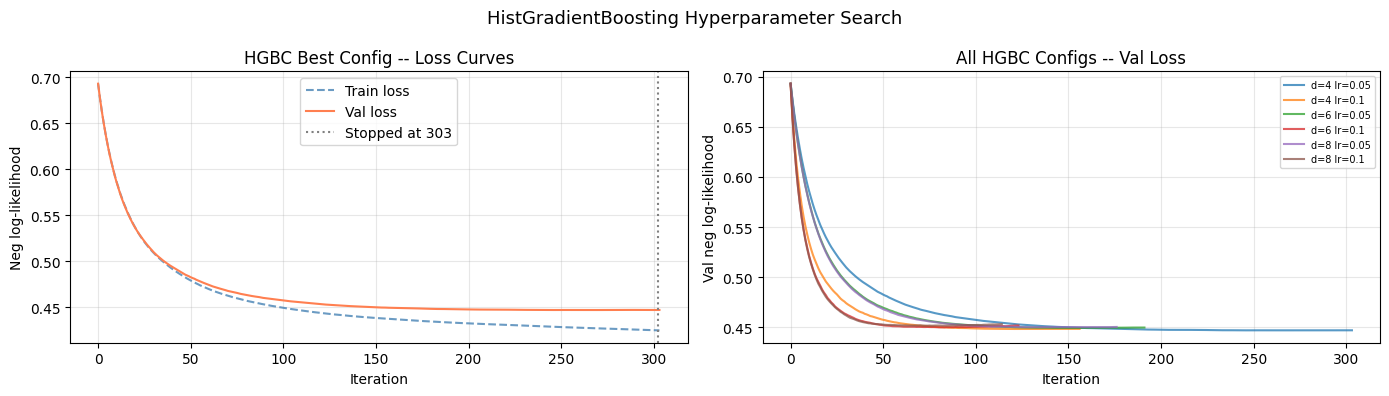

In [3]:
hgbc_grid = [
    {'max_depth': 4, 'learning_rate': 0.05},
    {'max_depth': 4, 'learning_rate': 0.10},
    {'max_depth': 6, 'learning_rate': 0.05},
    {'max_depth': 6, 'learning_rate': 0.10},
    {'max_depth': 8, 'learning_rate': 0.05},
    {'max_depth': 8, 'learning_rate': 0.10},
]

hgbc_records = []
print(f"{'depth':>6}  {'lr':>5}  {'iters':>6}  {'val_AUC':>8}  {'val_AP':>7}  {'val_F1':>7}")
print('-' * 52)
for p in hgbc_grid:
    m = HistGradientBoostingClassifier(
        max_iter=1000,
        max_depth=p['max_depth'],
        learning_rate=p['learning_rate'],
        class_weight='balanced',
        min_samples_leaf=30,
        l2_regularization=0.1,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=40,
        random_state=seed,
    )
    m.fit(X_fit, y_fit)
    proba_v = m.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, proba_v)
    val_ap  = average_precision_score(y_val, proba_v)
    val_f1, *_ = threshold_sweep(proba_v, y_val)
    n_iters = m.n_iter_
    hgbc_records.append(dict(max_depth=p['max_depth'], lr=p['learning_rate'],
                             n_iters=n_iters, val_auc=val_auc, val_ap=val_ap,
                             val_f1=val_f1, _model=m))
    print(f"{p['max_depth']:>6}  {p['learning_rate']:>5.2f}  {n_iters:>6}  "
          f"{val_auc:>8.4f}  {val_ap:>7.4f}  {val_f1:>7.4f}")

best_hgbc_idx = max(range(len(hgbc_records)), key=lambda i: hgbc_records[i]['val_f1'])
best_hgbc_rec = hgbc_records[best_hgbc_idx]
best_hgbc     = best_hgbc_rec['_model']
print(f"\nBest HGBC: depth={best_hgbc_rec['max_depth']}  "
      f"lr={best_hgbc_rec['lr']}  iters={best_hgbc_rec['n_iters']}  "
      f"val_F1={best_hgbc_rec['val_f1']:.4f}")

# Training curves: validation score per iteration for each config
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(-np.array(best_hgbc.train_score_),   color='steelblue', linestyle='--',
        alpha=0.8, label='Train loss')
ax.plot(-np.array(best_hgbc.validation_score_), color='coral',
        label='Val loss')
ax.axvline(best_hgbc_rec['n_iters'] - 1, color='gray', linestyle=':',
           label=f'Stopped at {best_hgbc_rec["n_iters"]}')
ax.set_xlabel('Iteration'); ax.set_ylabel('Neg log-likelihood')
ax.set_title('HGBC Best Config -- Loss Curves')
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
for rec in hgbc_records:
    m   = rec['_model']
    lbl = f"d={rec['max_depth']} lr={rec['lr']}"
    ax2.plot(-np.array(m.validation_score_), label=lbl, alpha=0.75)
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Val neg log-likelihood')
ax2.set_title('All HGBC Configs -- Val Loss')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

plt.suptitle('HistGradientBoosting Hyperparameter Search', fontsize=13)
plt.tight_layout(); plt.show()

In [4]:
res_xgb  = test_metrics(best_xgb,  'XGBoost')
res_hgbc = test_metrics(best_hgbc, 'HGBC')

# DT baselines (from decision_tree.ipynb)
dt_baseline = dict(label='DT baseline (no weight)',
                   f1=0.377, p=0.621, r=0.270, t=0.50, auc=0.814, ap=None, proba=None)
dt_f1opt    = dict(label='DT F1-opt (3x weight)',
                   f1=0.454, p=0.433, r=0.477, t=0.50, auc=0.848, ap=None, proba=None)

sep = '-' * 62
for res in [res_xgb, res_hgbc]:
    print(f'\n{sep}\n  {res["label"]}\n{sep}')
    print(f'  Default threshold (0.50):')
    print(classification_report(y_test, (res['proba'] >= 0.50).astype(int), digits=3))
    print(f'  F1-optimal threshold ({res["t"]:.2f}):')
    print(classification_report(y_test, (res['proba'] >= res['t']).astype(int), digits=3))
    print(f'  AUC={res["auc"]:.4f}   AP={res["ap"]:.4f}')

# Summary table
all_res = [dt_baseline, dt_f1opt, res_xgb, res_hgbc]
rows = []
for r in all_res:
    rows.append({
        'Model':     r['label'],
        'F1':        round(r['f1'],  4),
        'Precision': round(r['p'],   3),
        'Recall':    round(r['r'],   3),
        'AUC':       round(r['auc'], 4),
        'AP':        round(r['ap'],  4) if r['ap'] is not None else None,
        'Threshold': round(r['t'],   2),
    })
comp = pd.DataFrame(rows)
print('\n--- Summary (test set, F1-optimal threshold) ---')
print(comp.to_string(index=False))


--------------------------------------------------------------
  XGBoost
--------------------------------------------------------------
  Default threshold (0.50):
              precision    recall  f1-score   support

           0      0.976     0.833     0.899     50951
           1      0.261     0.743     0.387      4049

    accuracy                          0.827     55000
   macro avg      0.619     0.788     0.643     55000
weighted avg      0.923     0.827     0.861     55000

  F1-optimal threshold (0.78):
              precision    recall  f1-score   support

           0      0.960     0.954     0.957     50951
           1      0.467     0.505     0.485      4049

    accuracy                          0.921     55000
   macro avg      0.714     0.730     0.721     55000
weighted avg      0.924     0.921     0.923     55000

  AUC=0.8701   AP=0.4939

--------------------------------------------------------------
  HGBC
------------------------------------------------------

Computing permutation importance for XGBoost ...
Computing permutation importance for HGBC ...


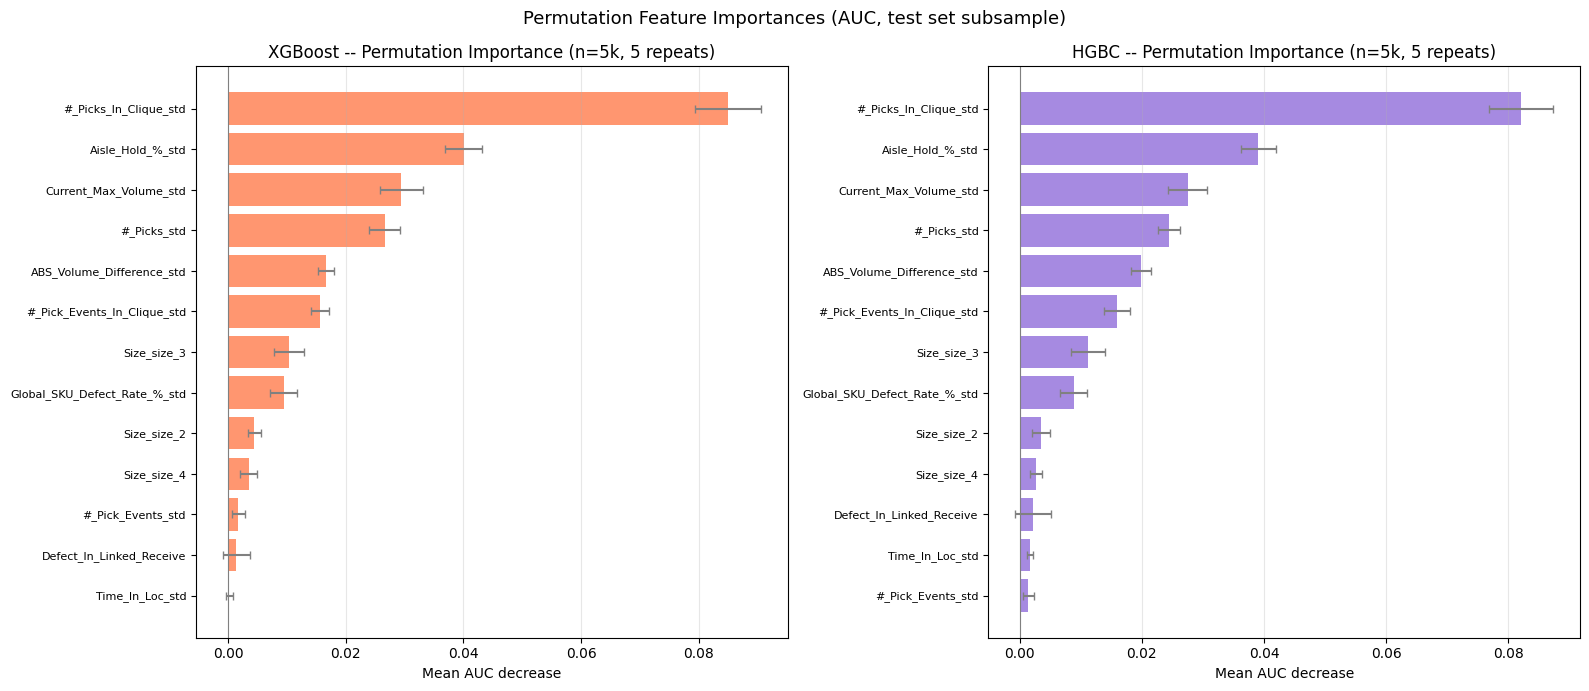

In [5]:
# Permutation importance: consistent across model families.
# Subsample 5k test rows for speed (full 55k would work but takes ~30s).
rng = np.random.RandomState(seed)
idx = rng.choice(len(X_test), 5000, replace=False)
X_sub, y_sub = X_test.iloc[idx], y_test.iloc[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_colors = {'XGBoost': 'coral', 'HGBC': 'mediumpurple'}
TOP_N = 15

for ax, (name, model) in zip(axes, [('XGBoost', best_xgb), ('HGBC', best_hgbc)]):
    print(f'Computing permutation importance for {name} ...')
    perm = permutation_importance(
        model, X_sub, y_sub,
        n_repeats=5, random_state=seed, scoring='roc_auc'
    )
    fi = pd.Series(perm.importances_mean, index=X_test.columns)
    fi_std = pd.Series(perm.importances_std,  index=X_test.columns)
    fi_top = fi.sort_values(ascending=False).head(TOP_N)
    fi_std_top = fi_std[fi_top.index]
    n_top = len(fi_top)  # actual features shown (capped by feature count)

    ax.barh(range(n_top), fi_top.values[::-1],
            xerr=fi_std_top.values[::-1],
            color=plot_colors[name], alpha=0.82,
            error_kw=dict(ecolor='gray', capsize=3))
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(fi_top.index[::-1], fontsize=8)
    ax.set_xlabel('Mean AUC decrease')
    ax.set_title(f'{name} -- Permutation Importance (n=5k, 5 repeats)')
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Permutation Feature Importances (AUC, test set subsample)', fontsize=13)
plt.tight_layout(); plt.show()

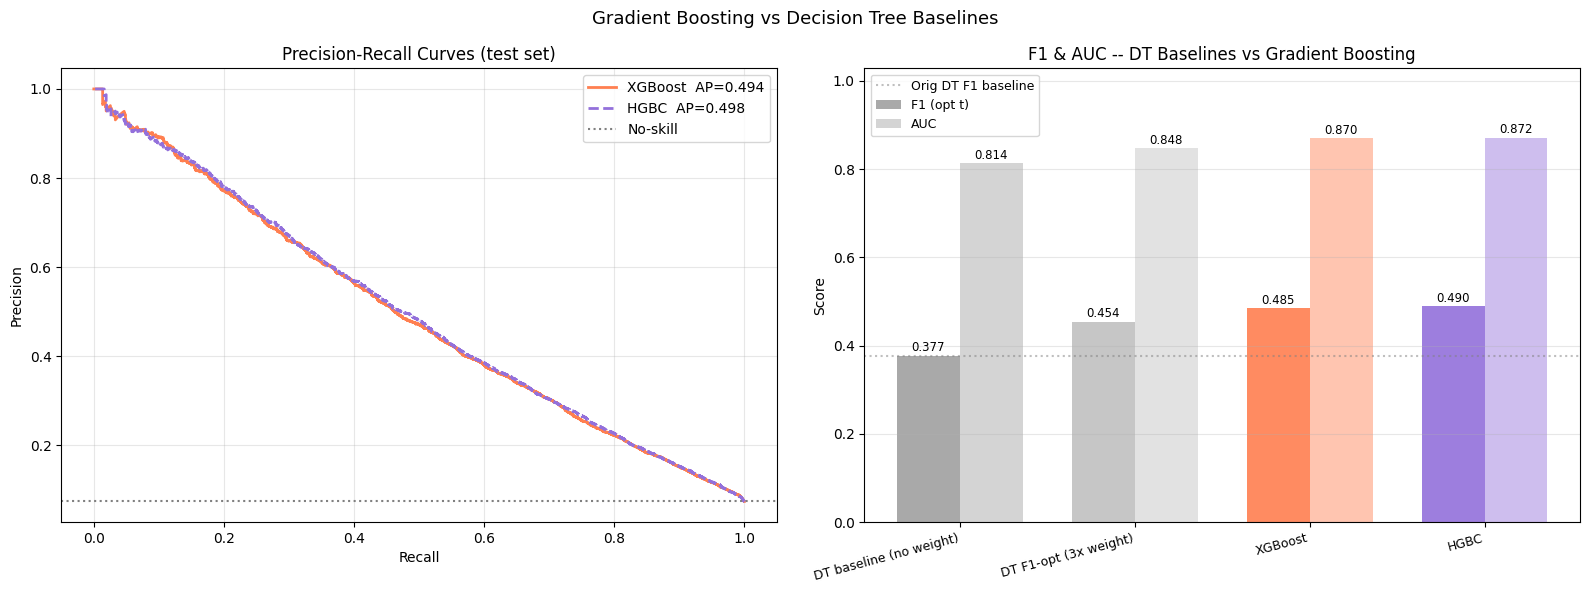

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR curves (GBM models only -- DT baselines have no stored probas here)
ax = axes[0]
for res, color, ls in [
    (res_xgb,  'coral',        '-'),
    (res_hgbc, 'mediumpurple', '--'),
]:
    p, r, _ = precision_recall_curve(y_test, res['proba'])
    ax.plot(r, p, color=color, linestyle=ls, linewidth=2,
            label=f"{res['label']}  AP={res['ap']:.3f}")
ax.axhline(y_test.mean(), color='gray', linestyle=':', label='No-skill')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (test set)')
ax.legend(); ax.grid(alpha=0.3)

# Grouped bar: F1 and AUC for all 4 models
ax2 = axes[1]
model_labels = [r['label'] for r in all_res]
f1_vals  = [r['f1']  for r in all_res]
auc_vals = [r['auc'] for r in all_res]
x = np.arange(len(model_labels))
w = 0.36
bar_colors = ['#a0a0a0', '#c0c0c0', 'coral', 'mediumpurple']
b1 = ax2.bar(x - w/2, f1_vals,  w, color=bar_colors, alpha=0.90, label='F1 (opt t)')
b2 = ax2.bar(x + w/2, auc_vals, w, color=bar_colors, alpha=0.45, label='AUC')
for bar, val in list(zip(b1, f1_vals)) + list(zip(b2, auc_vals)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
ax2.axhline(0.377, color='gray', linestyle=':', alpha=0.5, label='Orig DT F1 baseline')
ax2.set_xticks(x)
ax2.set_xticklabels(model_labels, rotation=15, ha='right', fontsize=9)
ax2.set_ylim(0, max(auc_vals) * 1.18)
ax2.set_ylabel('Score')
ax2.set_title('F1 & AUC -- DT Baselines vs Gradient Boosting')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Gradient Boosting vs Decision Tree Baselines', fontsize=13)
plt.tight_layout(); plt.show()